# Notebook 2 — Data Cleaning, Preprocessing & Dimensionality Reduction

Based on the EDA, we now know what needs to be cleaned up before modeling. This notebook handles column drops, null checks, outlier removal, scaling, and saves a clean CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style('darkgrid')

df = pd.read_csv('../data/train.csv')
print('Original shape:', df.shape)
df.head(3)

Original shape: (28362, 24)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0


## Step 1 — Drop non-feature columns

Several columns aren't useful for clustering — they're either identifiers, raw text, or categorical labels that don't add numeric signal.

In [2]:
# drop index column, raw text, and non-numeric identifiers
# keeping genre and topic as reference columns but not feeding them to the model
cols_to_drop = ['Unnamed: 0', 'lyrics', 'artist_name', 'track_name', 'release_date']

df_clean = df.drop(columns=cols_to_drop)
print('Shape after dropping identifier columns:', df_clean.shape)

Shape after dropping identifier columns: (28362, 19)


## Step 2 — Handle nulls

In [3]:
# check for any missing values
null_counts = df_clean.isnull().sum()
print('Null counts per column:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No nulls found — dataset is clean.')

Null counts per column:
No nulls found — dataset is clean.


## Step 3 — Outlier removal using Z-Score

We'll remove rows where any numeric lyrical feature has a Z-Score beyond 3.5 standard deviations. This keeps the bulk of the data while removing extreme edge cases.

In [4]:
from scipy import stats

# numeric feature columns used for modeling
feature_cols = ['dating','violence','world/life','night/time','shake the audience',
                'family/gospel','romantic','communication','obscene','music',
                'movement/places','light/visual perceptions','family/spiritual',
                'sadness','feelings','age','len']

# calculate z-scores across all numeric features
z_scores = np.abs(stats.zscore(df_clean[feature_cols]))

# keep only rows where all z-scores are within 3.5 std
mask = (z_scores < 3.5).all(axis=1)
df_clean = df_clean[mask].reset_index(drop=True)

print(f'Rows removed: {(~mask).sum()}')
print(f'Shape after outlier removal: {df_clean.shape}')

Rows removed: 5702
Shape after outlier removal: (22660, 19)


## Step 4 — Scale numeric features

KMeans is distance-based, so features on different scales will dominate the clustering. StandardScaler brings everything to the same scale.

In [5]:
scaler = StandardScaler()

# fit and transform only the feature columns
scaled_features = scaler.fit_transform(df_clean[feature_cols])

# put scaled data back into a dataframe
df_scaled = pd.DataFrame(scaled_features, columns=feature_cols)

# add back genre and topic for reference later
df_scaled['genre'] = df_clean['genre'].values
df_scaled['topic'] = df_clean['topic'].values

print('Scaled dataframe shape:', df_scaled.shape)
df_scaled.head(3)

Scaled dataframe shape: (22660, 19)


,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age,len,genre,topic
0,-0.436394,-0.354105,-0.749963,-0.549950,-0.472758,1.271131,-0.291012,1.703518,-0.565828,-0.136526,-0.550882,-0.586123,-0.530978,1.300784,2.198986,2.251543,0.477025,pop,sadness
1,0.527025,-0.168362,1.798944,-0.542566,-0.448574,0.489092,-0.482724,-0.745305,-0.562031,0.617201,-0.542590,2.116940,0.797207,-0.762414,-0.517256,2.251543,-0.566668,pop,world/life
2,-0.376503,-0.696993,-0.737461,-0.526557,-0.396144,-0.378414,1.423178,1.581454,-0.553798,2.586674,-0.524615,-0.558440,-0.473882,-0.754322,4.736049,2.251543,-1.207115,pop,music


## Step 5 — PCA for Dimensionality Reduction

We have 17 numeric features. PCA lets us reduce this down while retaining most of the variance — we'll visualize how many components are needed.

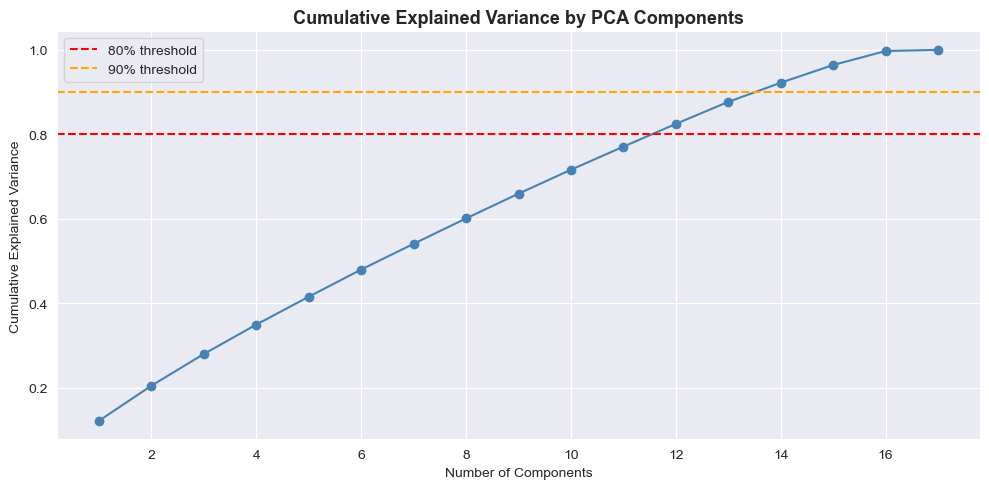

Components needed for 80% variance: 12
Components needed for 90% variance: 14


In [6]:
# run PCA on all 17 features to see explained variance
pca_full = PCA()
pca_full.fit(scaled_features)

explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(explained)+1), explained, marker='o', color='steelblue')
ax.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
ax.axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
ax.set_title('Cumulative Explained Variance by PCA Components', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

# find number of components for 80% and 90%
n_80 = next(i+1 for i, v in enumerate(explained) if v >= 0.80)
n_90 = next(i+1 for i, v in enumerate(explained) if v >= 0.90)
print(f'Components needed for 80% variance: {n_80}')
print(f'Components needed for 90% variance: {n_90}')

In [7]:
# apply PCA keeping enough components for 90% variance
pca = PCA(n_components=n_90)
pca_result = pca.fit_transform(scaled_features)

# build a dataframe with the PCA components
pca_cols = [f'PC{i+1}' for i in range(n_90)]
df_pca = pd.DataFrame(pca_result, columns=pca_cols)

# add back reference columns
df_pca['genre'] = df_clean['genre'].values
df_pca['topic'] = df_clean['topic'].values

print('PCA dataframe shape:', df_pca.shape)
df_pca.head(3)

PCA dataframe shape: (22660, 16)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,genre,topic
0,-1.398076,-1.278981,-0.571528,-0.507212,-0.674995,-1.900005,-0.079108,0.742477,1.194157,1.014177,1.389519,-0.570283,-0.165900,2.002926,pop,sadness
1,-1.699970,1.906363,1.841023,1.233175,-0.123971,0.273687,-0.254658,-1.146926,0.008897,-0.951868,0.219816,-0.621364,0.584668,1.604556,pop,world/life
2,-2.697900,-1.218182,0.935964,0.132908,0.895386,-2.600580,1.882863,0.091561,3.695177,2.844402,0.141254,0.058905,0.374594,0.876427,pop,music


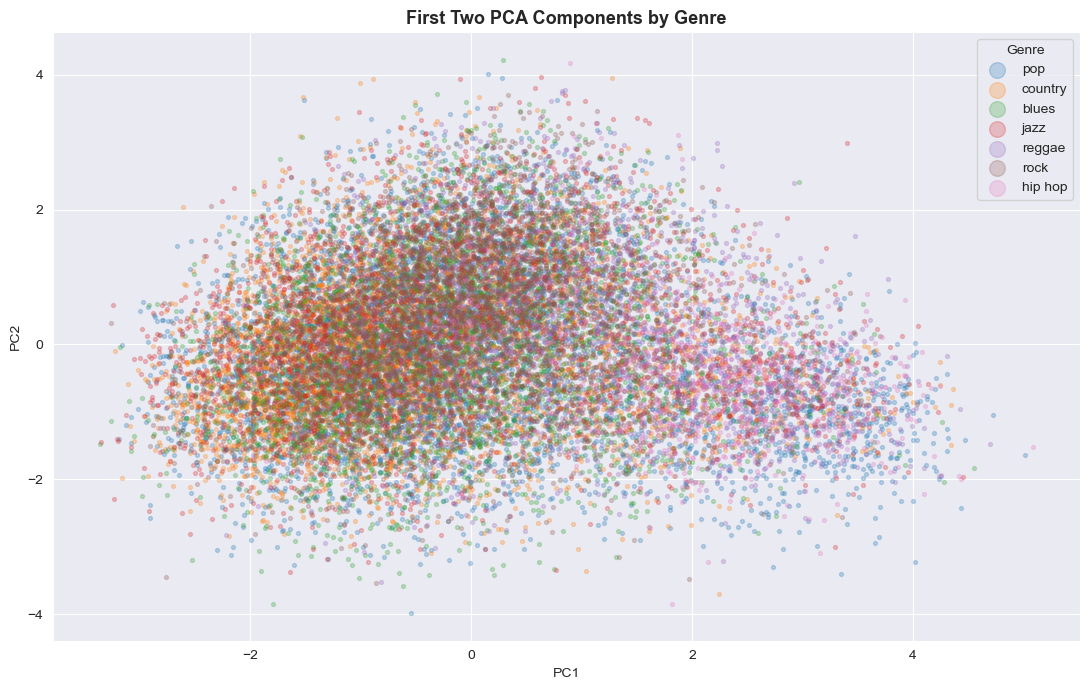

In [8]:
# visualize first two PCA components colored by genre
fig, ax = plt.subplots(figsize=(11, 7))
genres = df_pca['genre'].unique()
palette = sns.color_palette('tab10', len(genres))

for i, genre in enumerate(genres):
    subset = df_pca[df_pca['genre'] == genre]
    ax.scatter(subset['PC1'], subset['PC2'], alpha=0.25, s=8,
               color=palette[i], label=genre)

ax.set_title('First Two PCA Components by Genre', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=4, title='Genre')
plt.tight_layout()
plt.show()

## Step 6 — Save cleaned data

In [9]:
# save the PCA-reduced dataframe — this is what the model notebook will use
df_pca.to_csv('../data/train_processed.csv', index=False)
print('Saved train_processed.csv')
print('Final shape:', df_pca.shape)

Saved train_processed.csv
Final shape: (22660, 16)
